**Libraries**

In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio

import darksun as ds
from darksun.utils import savefig_to

**Analysis Methods**

In [ ]:
def config_snrlim(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures significance histograms values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf significance limit.
        stop (int | float): Sup significance limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max else None)
    return slice_bins, slice_hist

**Notebook's General Variables**

In [14]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG'
#SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_bm'
SAVE_THINGS: bool = True

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = True

**Load Mask and Data**

In [15]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID_new: str = "singleCAM_iros_testing_PSF_newSGmodel"
ANALYSIS_ID_bm: str = "singleCAM_iros_testing_PSF_BMmodel"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

In [16]:
# load filepaths
mask_path, simul_data, save_path_new = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID_new,
)
_, _, save_path_bm = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID_bm,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [17]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])                                              # same data
true_sky_camA, _ = ds.load_sky(save_path_new + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID_new}.fits")   # same data

res_sky_camA_new, _ = ds.load_sky(save_path_new + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID_new}.fits")

res_sky_camA_bm, _ = ds.load_sky(save_path_bm + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID_bm}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [18]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])                                              # same data
true_sky_camB, _ = ds.load_sky(save_path_new + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID_new}.fits")   # same data   

res_sky_camB_new, _ = ds.load_sky(save_path_new + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID_new}.fits")

res_sky_camB_bm, _ = ds.load_sky(save_path_bm + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID_bm}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


**Analysis for LEM-X Camera A**

In [19]:
assert ANALYSIS_CAM1A

## USING BULK MASK with 1.5 mm cover ##


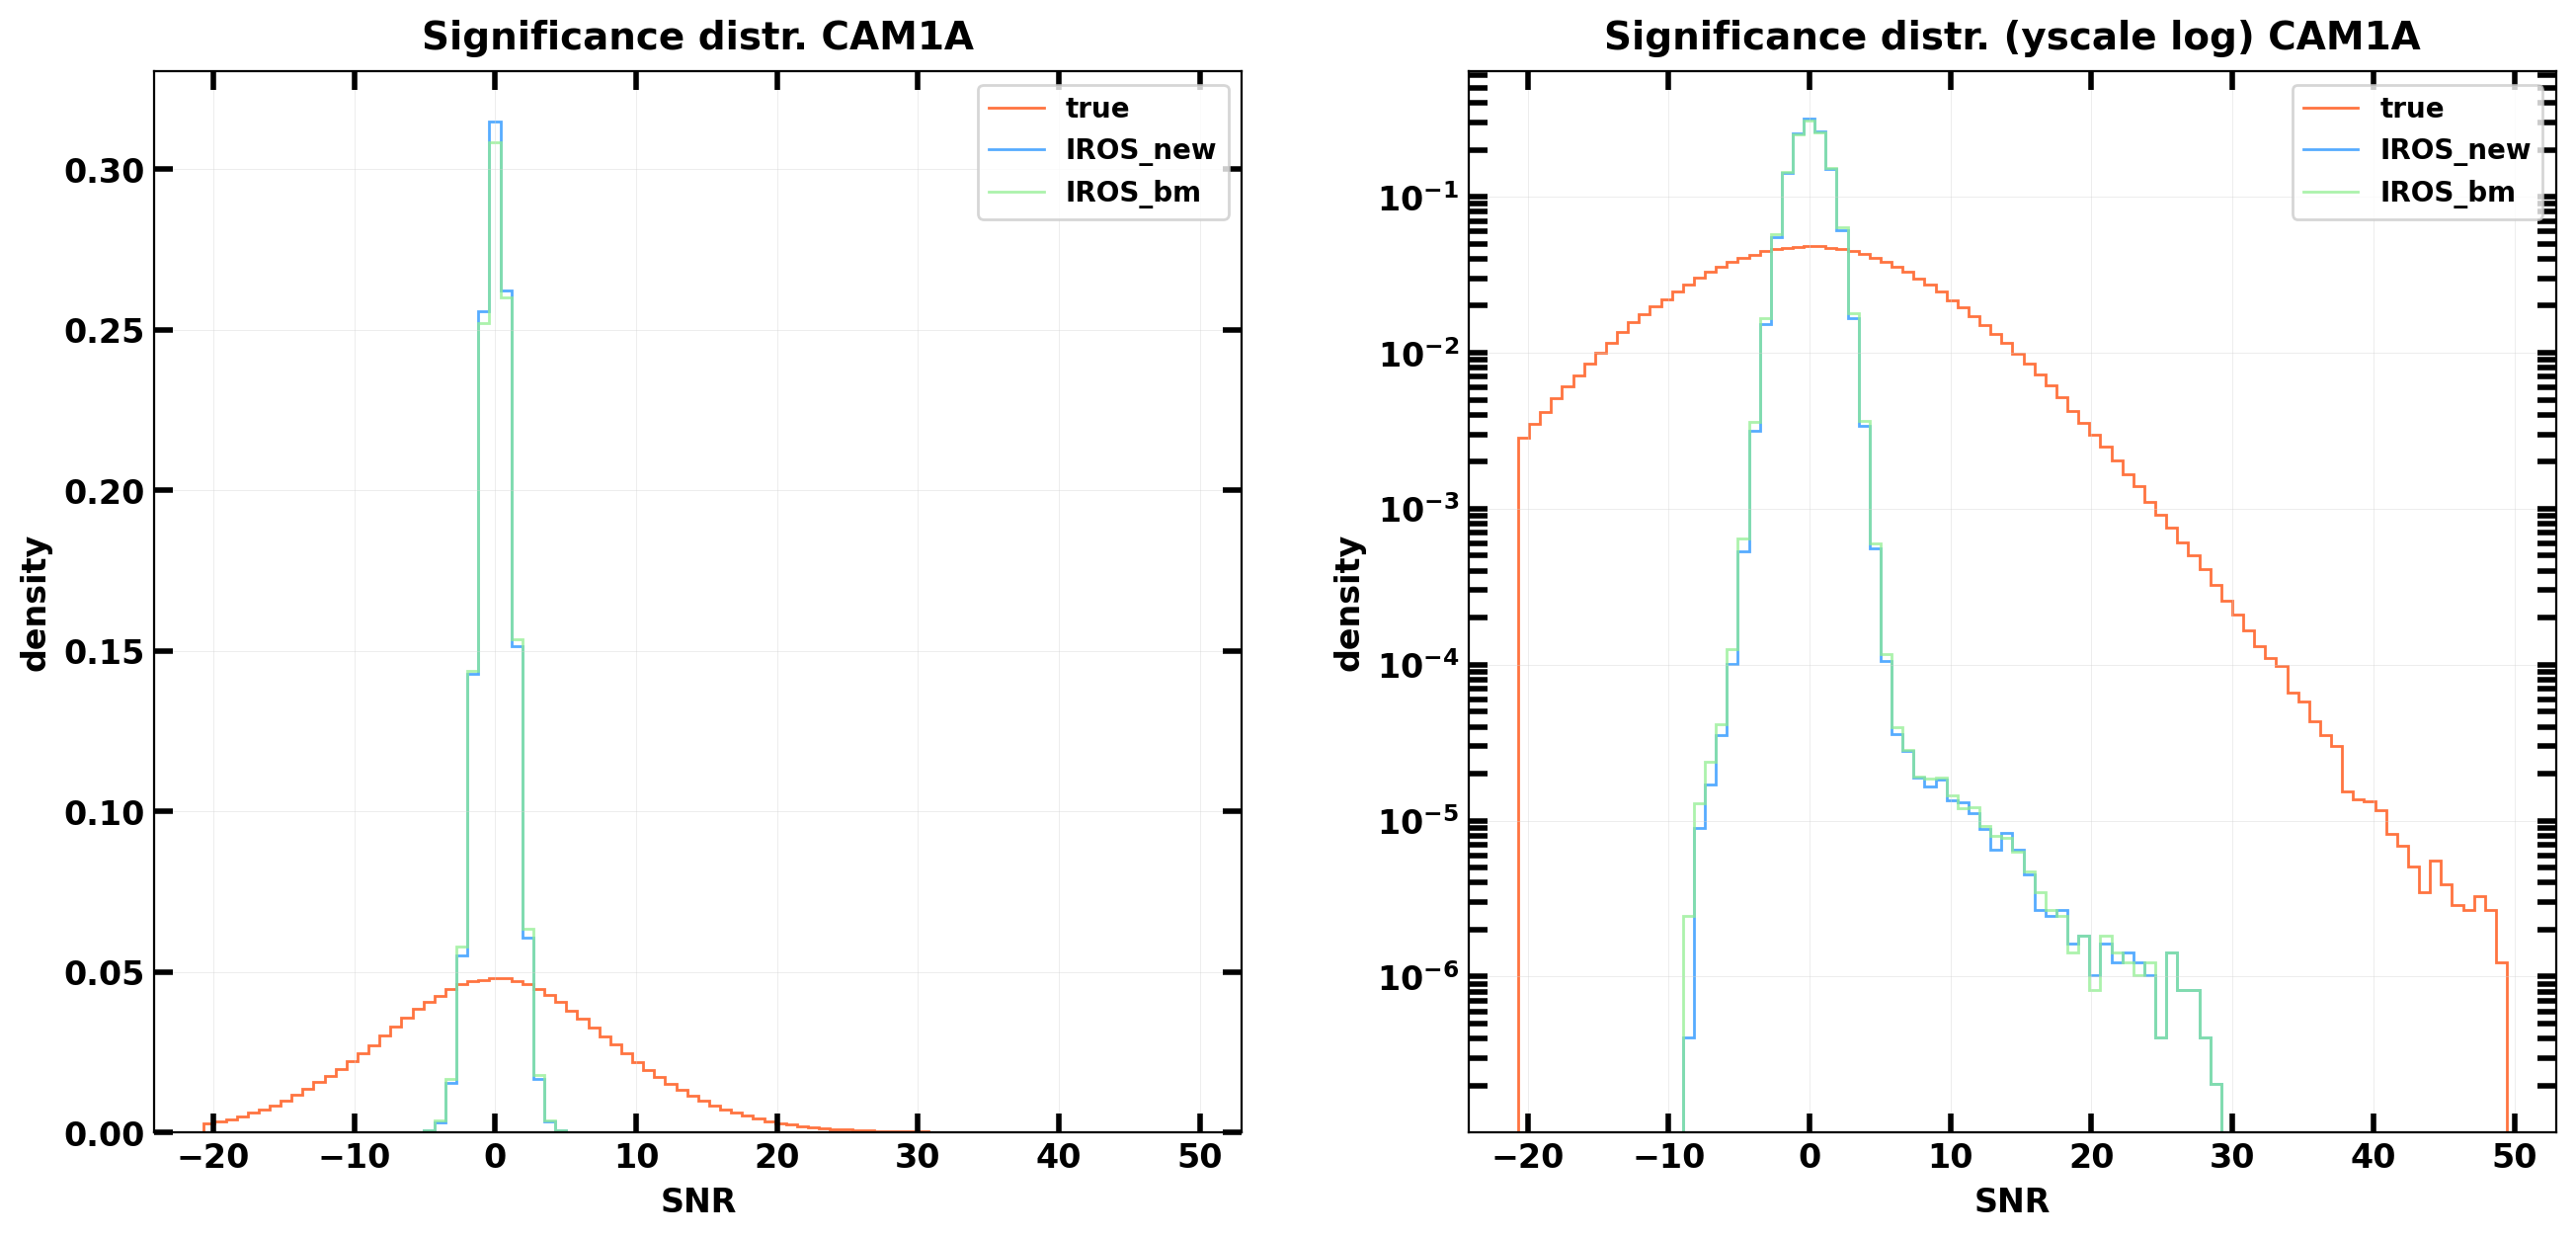

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camA = count(wfm, sdlA.DLdata)[0]
varmap = variance(wfm, detector_camA)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)

res_skysnr_camA_new, res_skysnr_camA_bm = map(
    lambda x: ds.unframe(snratio(x, varmap), ycut, xcut),
    (res_sky_camA_new, res_sky_camA_bm)
)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)

hist_res_skysnr_new, _ = np.histogram(res_skysnr_camA_new, bins=bins, density=density)
hist_res_skysnr_bm, _ = np.histogram(res_skysnr_camA_bm, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr_new[hist_slice], hist_res_skysnr_bm[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS_new', 'IROS_bm'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue', 'LightGreen'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr_new[hist_slice], hist_res_skysnr_bm[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS_new', 'IROS_bm'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue', 'LightGreen'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

**Analysis for LEM-X Camera B**

In [21]:
assert ANALYSIS_CAM1B

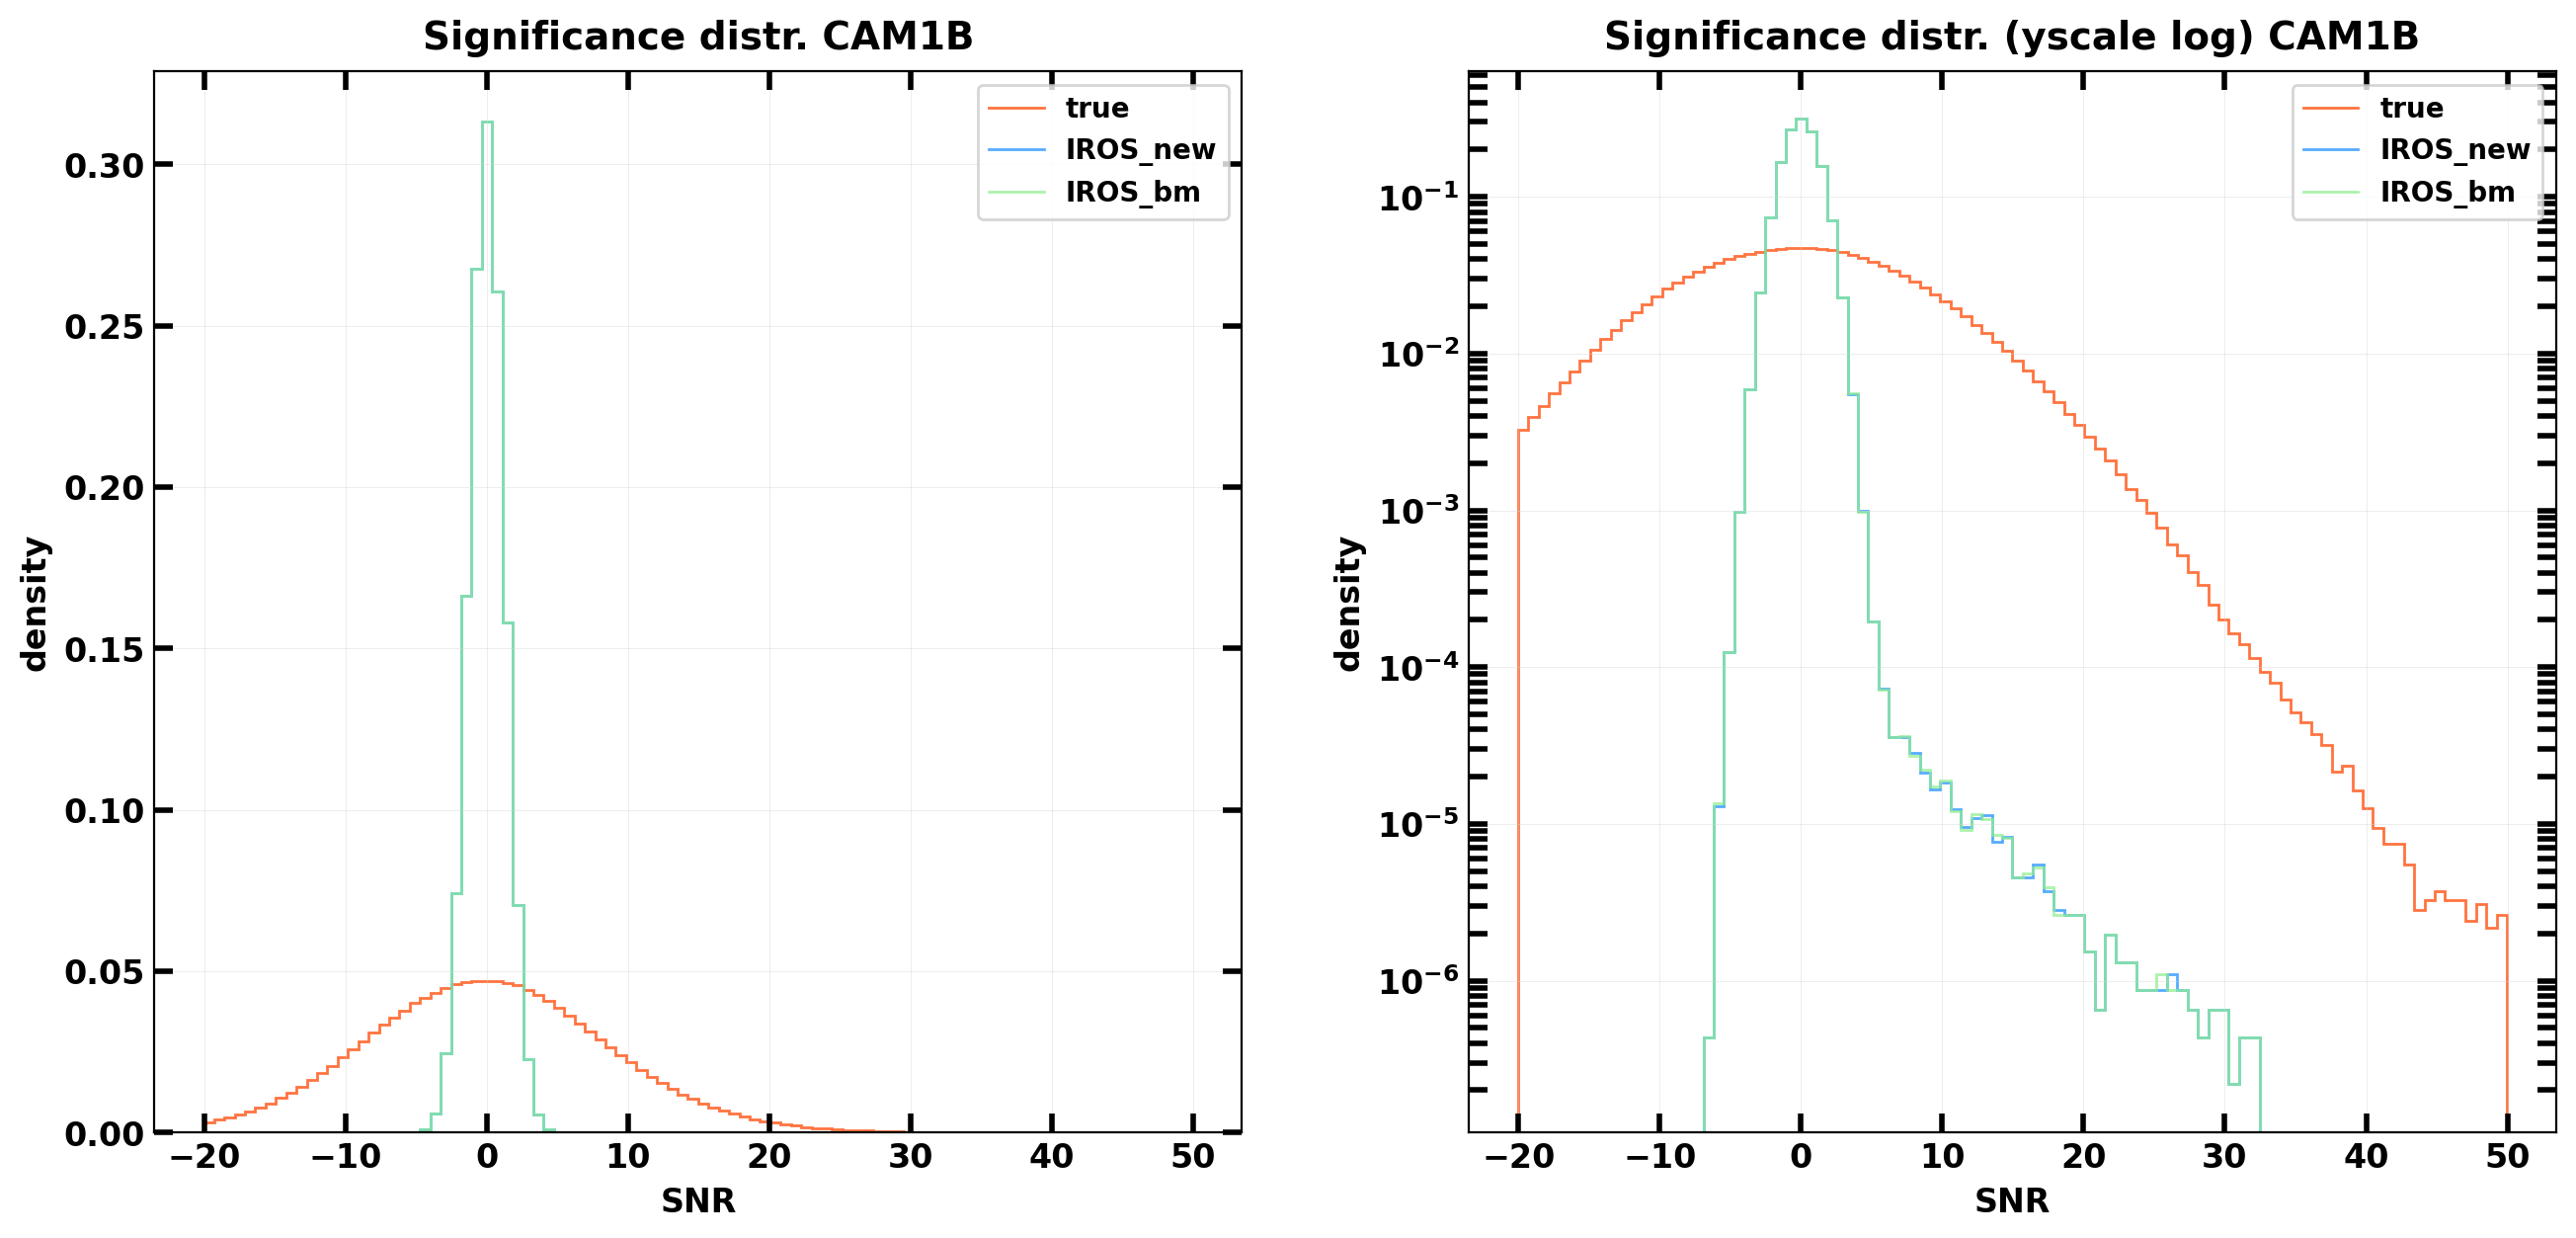

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camB = count(wfm, sdlB.DLdata)[0]
varmap = variance(wfm, detector_camB)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camB = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)

res_skysnr_camB_new, res_skysnr_camB_bm = map(
    lambda x: ds.unframe(snratio(x, varmap), ycut, xcut),
    (res_sky_camA_new, res_sky_camA_bm)
)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camB, bins=num_bins, density=density)

hist_res_skysnr_new, _ = np.histogram(res_skysnr_camB_new, bins=bins, density=density)
hist_res_skysnr_bm, _ = np.histogram(res_skysnr_camB_bm, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr_new[hist_slice], hist_res_skysnr_bm[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS_new', 'IROS_bm'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue', 'LightGreen'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr_new[hist_slice], hist_res_skysnr_bm[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS_new', 'IROS_bm'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue', 'LightGreen'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)